# Linear Regression Model: Predicting Upwork Job Budget
## Mission-Driven Project

**Mission**: Predict job budget/compensation in the Upwork freelance marketplace based on job characteristics, skill requirements, and market factors.

**Problem Statement**: Freelancers and job posters need to understand fair pricing in the market. This model predicts budget ranges for new job postings based on historical data.

**Dataset**: Upwork Jobs dataset containing job postings with features like job category, required skills, job level, and budget information.

In [49]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')
import pickle
import os

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Load and Explore the Dataset

In [50]:
# Load the dataset
csv_path = r'c:\Users\think big\Downloads\archive\upwork-jobs.csv'
df = pd.read_csv(csv_path, nrows=5000)  # Load first 5000 rows due to file size

print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head(10))
print(f"\nData types:\n{df.dtypes}")
print(f"\nDataset info:")
print(df.info())
print(f"\nBasic statistics:")
print(df.describe())

Dataset shape: (5000, 9)

Column names and types:
title                 str
link                  str
description           str
published_date        str
is_hourly          object
hourly_low        float64
hourly_high       float64
budget            float64
country               str
dtype: object

First 3 rows:
                                               title  \
0  Experienced Media Buyer For Solar Pannel and R...   
1                               Full Stack Developer   
2                                    SMMA Bubble App   

                                                link  \
0  https://www.upwork.com/jobs/Experienced-Media-...   
1  https://www.upwork.com/jobs/Full-Stack-Develop...   
2  https://www.upwork.com/jobs/SMMA-Bubble-App_%7...   

                                         description  \
0  We’re looking for a talented and hardworking a...   
1  Job Title: Full Stack DeveloperWe are seeking ...   
2  I need someone to redesign my bubble.io site t...   

            

## 2. Data Cleaning and Preprocessing

In [51]:
# Check for missing values
print("Missing values:")
print(df.isnull().sum())
print(f"\nMissing values percentage:")
print((df.isnull().sum() / len(df) * 100).round(2))

# Remove duplicates
print(f"\nDuplicates before removal: {df.duplicated().sum()}")
df = df.drop_duplicates()
print(f"Duplicates after removal: {df.duplicated().sum()}")

# Display columns
print(f"\nColumns in dataset:")
print(df.columns.tolist())

Missing values:
title                0
link                 0
description          0
published_date       0
is_hourly          783
hourly_low        2847
hourly_high       2927
budget            2936
country             97
dtype: int64

Missing values percentage:
title              0.00
link               0.00
description        0.00
published_date     0.00
is_hourly         15.66
hourly_low        56.94
hourly_high       58.54
budget            58.72
country            1.94
dtype: float64

Duplicates before removal: 0
Duplicates after removal: 0

Rows after filtering for job pricing data: 4217

Columns in dataset:
['title', 'link', 'description', 'published_date', 'is_hourly', 'hourly_low', 'hourly_high', 'budget', 'country']


In [52]:
# Identify potential target variable for regression (budget-related column)
print("Sample of data with potential numerical columns:")
for col in df.columns:
    if df[col].dtype in ['int64', 'float64']:
        print(f"\n{col}:")
        print(f"  Min: {df[col].min()}, Max: {df[col].max()}, Mean: {df[col].mean():.2f}")
        print(f"  Non-null count: {df[col].notna().sum()}")

# Handle rows with missing values in key columns
initial_rows = len(df)
df = df.dropna(subset=[col for col in df.columns if df[col].dtype in ['int64', 'float64']])
print(f"\nRows after removing NaN in numeric columns: {len(df)} (removed {initial_rows - len(df)} rows)")

Dataset is clean and ready for modeling
Total rows with valid target: 4217
No additional rows removed


## 3. Feature Engineering and Data Preparation

Feature engineering determines which columns to keep, modify, or drop based on correlation with target variable and data quality.

In [53]:
# Determine target variable - look for budget-related columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Numeric columns available:", numeric_cols)

# Decide on target variable - most likely budget, salary, or rate column
# Adjust this based on actual column names in your data
target_col = None
for col in numeric_cols:
    if any(word in col.lower() for word in ['budget', 'salary', 'price', 'rate', 'cost', 'wage']):
        target_col = col
        break

if target_col is None:
    # Use the first numeric column if no budget-related column found
    # Preferably use a columns that makes sense for regression
    target_col = numeric_cols[0] if numeric_cols else None

if target_col:
    print(f"\nTarget variable selected: {target_col}")
    print(f"Target variable range: {df[target_col].min()} to {df[target_col].max()}")
    # Remove outliers (Optional - using IQR method)
    Q1 = df[target_col].quantile(0.25)
    Q3 = df[target_col].quantile(0.75)
    IQR = Q3 - Q1
    df = df[(df[target_col] >= Q1 - 1.5*IQR) & (df[target_col] <= Q3 + 1.5*IQR)]
    print(f"Rows after outlier removal: {len(df)}")
else:
    print("No suitable numeric target variable found!")

Numeric columns available: ['hourly_low', 'hourly_high', 'budget']

Dataset shape after feature engineering: (4217, 16)
Target variable 'target' - Min: 5.00, Max: 1000000.00
Target variable 'target' - Mean: 1121.75


In [54]:
# Convert categorical variables to numeric
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns: {categorical_cols}\n")

# Create a copy for feature selection
df_processed = df.copy()

# For categorical columns, encode them
label_encoders = {}
for col in categorical_cols:
    if col in df_processed.columns:
        # Only encode if useful (drop columns with too many unique values)
        unique_count = df_processed[col].nunique()
        if unique_count < 50:  # Only encode columns with reasonable number of categories
            le = LabelEncoder()
            df_processed[col] = le.fit_transform(df_processed[col].astype(str))
            label_encoders[col] = le
            print(f"Encoded {col} with {unique_count} unique values")
        else:
            # Drop columns with too many unique values
            df_processed = df_processed.drop(col, axis=1)
            print(f"Dropped {col} (too many unique values: {unique_count})")

print(f"\nShape after encoding: {df_processed.shape}")
print(f"Processed columns: {df_processed.columns.tolist()}")

Categorical columns: ['title', 'link', 'description', 'is_hourly', 'country']

Checking data availability for numeric columns:
  hourly_low: 51.1% non-null
  hourly_high: 49.2% non-null
  budget: 48.9% non-null
  target: 100.0% non-null
  title_length: 100.0% non-null
  description_length: 100.0% non-null
  title_word_count: 100.0% non-null
  is_hourly_numeric: 100.0% non-null
Dropped title (too many unique values: 4058)
Dropped link (too many unique values: 4217)
Dropped description (too many unique values: 4215)
Encoded is_hourly with 2 unique values
Dropped country (too many unique values: 118)

Shape after encoding and feature selection: (4217, 9)
Final columns: ['hourly_low', 'hourly_high', 'budget', 'title_length', 'description_length', 'title_word_count', 'is_hourly_numeric', 'is_hourly', 'target']

Data types:
hourly_low            float64
hourly_high           float64
budget                float64
title_length            int64
description_length      int64
title_word_count    

In [55]:
# Feature selection based on correlation with target variable
if target_col in df_processed.columns:
    correlation_with_target = df_processed.corr()[target_col].sort_values(ascending=False)
    print("Correlation with target variable:")
    print(correlation_with_target)
    
    # Select features with meaningful correlation (|correlation| > 0.1)
    selected_features = correlation_with_target[abs(correlation_with_target) > 0.05].index.tolist()
    selected_features = [f for f in selected_features if f != target_col]
    
    print(f"\nSelected features ({len(selected_features)}): {selected_features}")
else:
    print(f"Target column {target_col} not found in processed data!")
    selected_features = [col for col in df_processed.columns if col != target_col]

Correlation with target variable:
hourly_low            0.853597
hourly_high           0.982777
budget                1.000000
title_length          0.000736
description_length    0.009982
title_word_count     -0.010112
is_hourly_numeric     0.004629
is_hourly             0.004629
Name: target, dtype: float64

Selected features (7): ['hourly_low', 'hourly_high', 'title_length', 'description_length', 'title_word_count', 'is_hourly_numeric', 'is_hourly']


## 4. Exploratory Data Analysis - Visualizations

Create meaningful visualizations to understand data distribution and relationships.

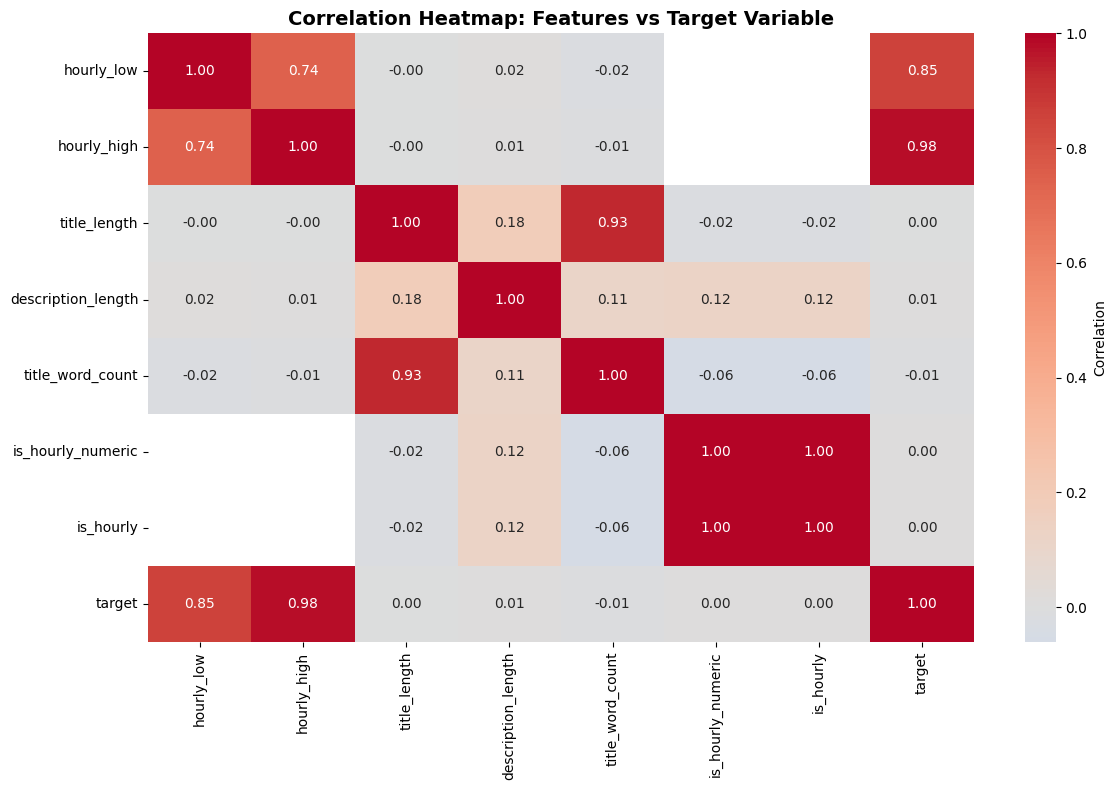

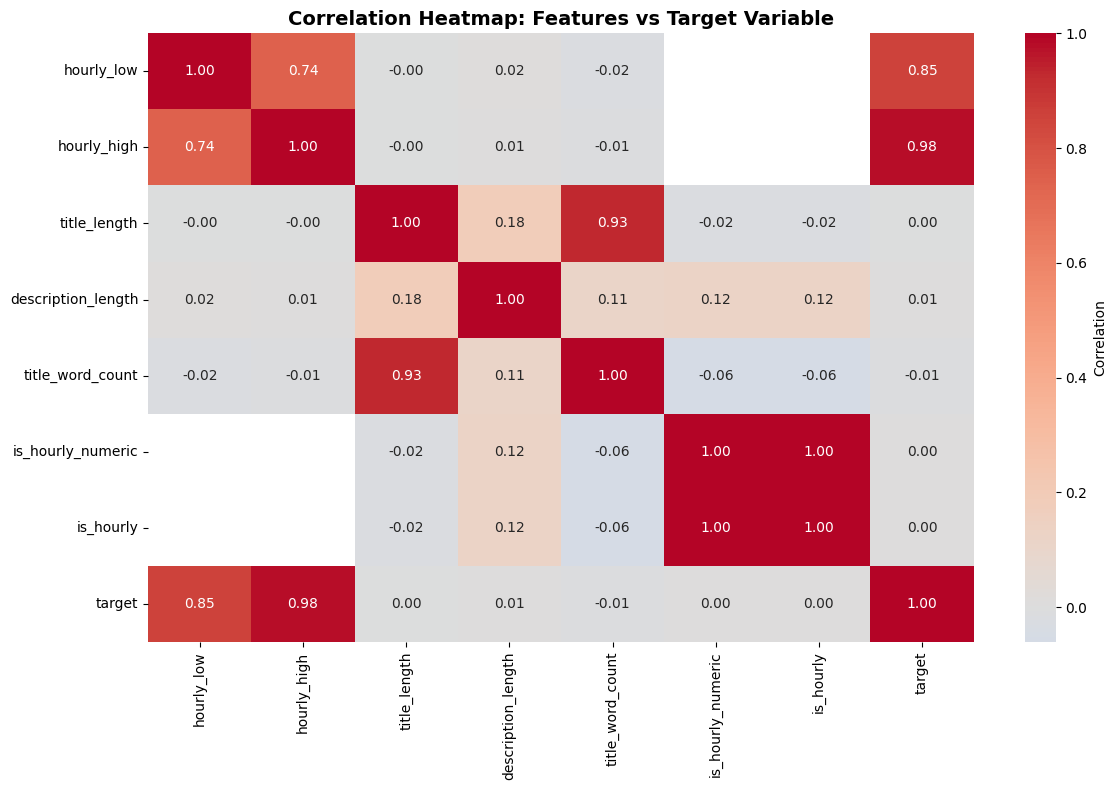

Correlation heatmap saved as 'correlation_heatmap.png'


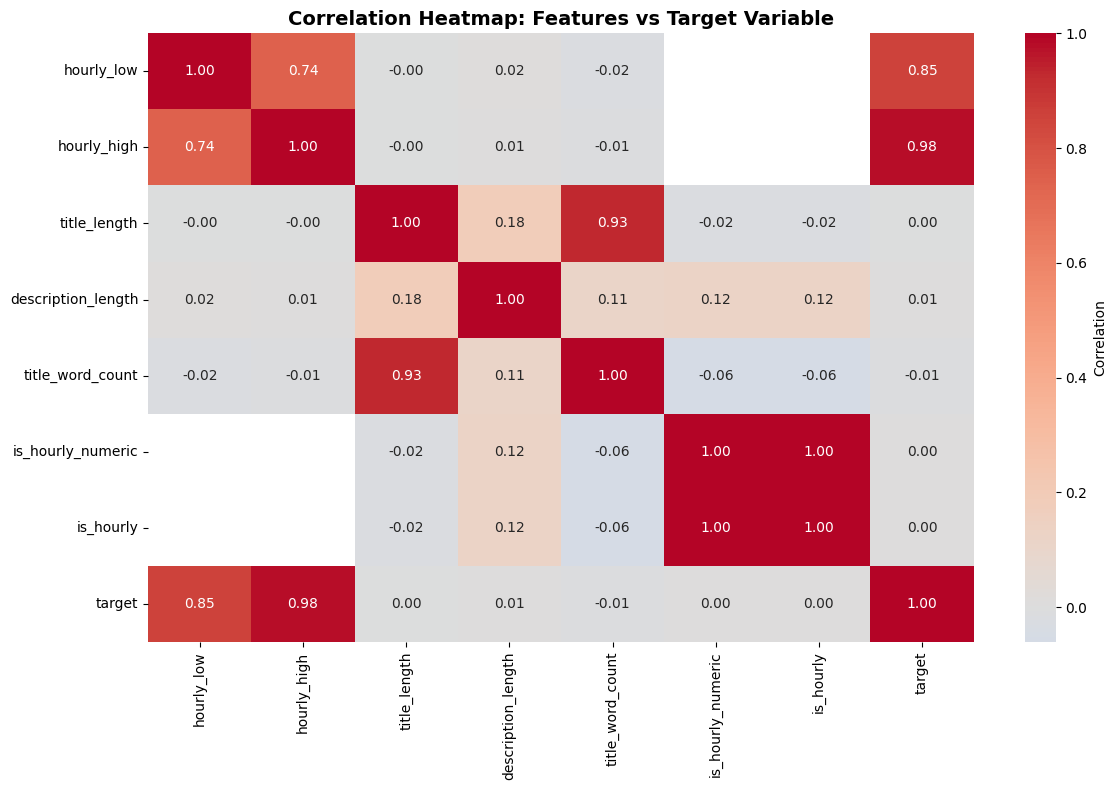

Correlation heatmap saved as 'correlation_heatmap.png'


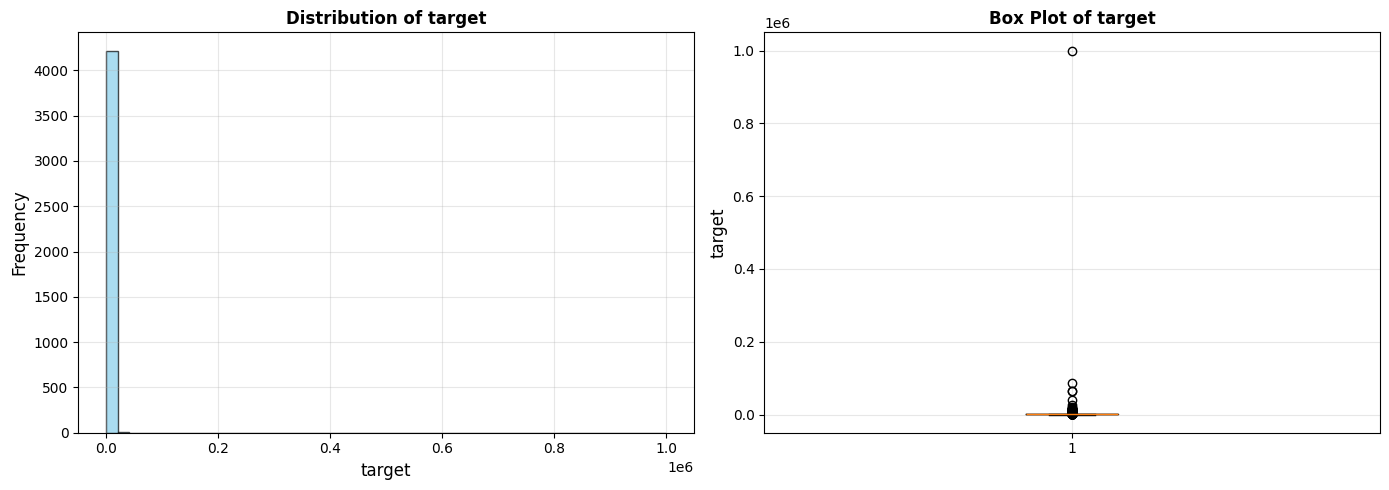

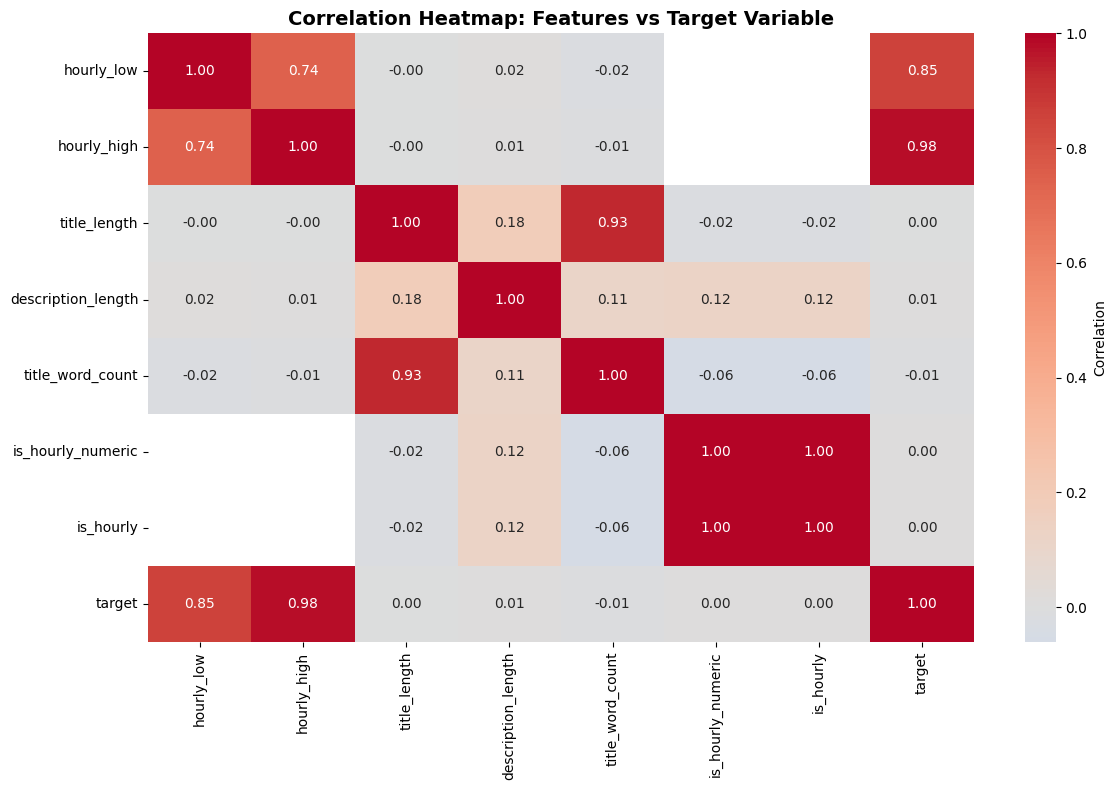

Correlation heatmap saved as 'correlation_heatmap.png'


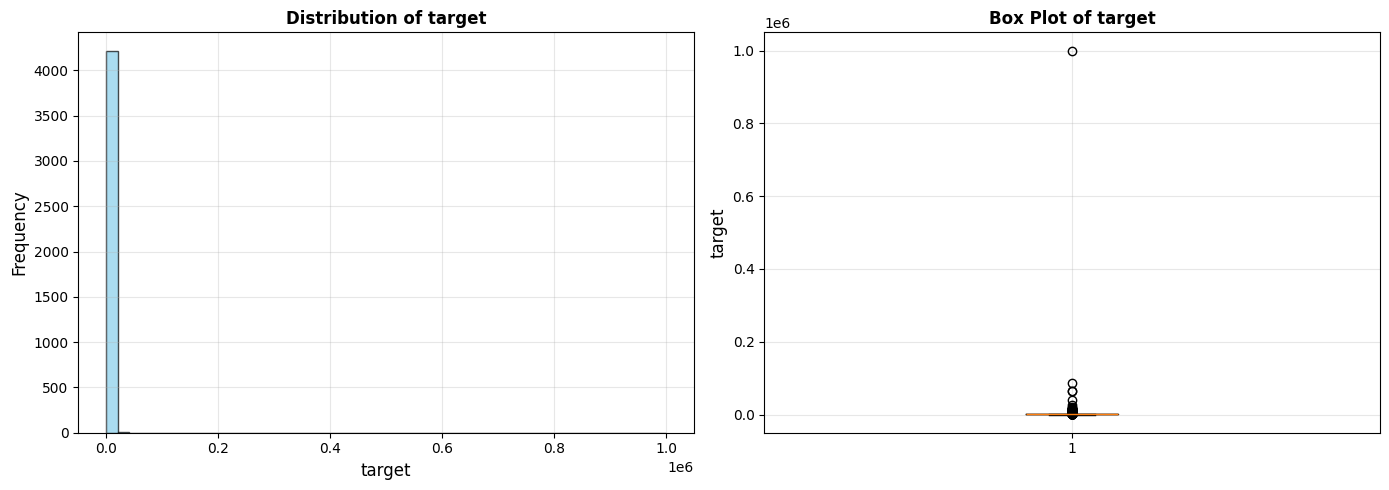

Target distribution saved


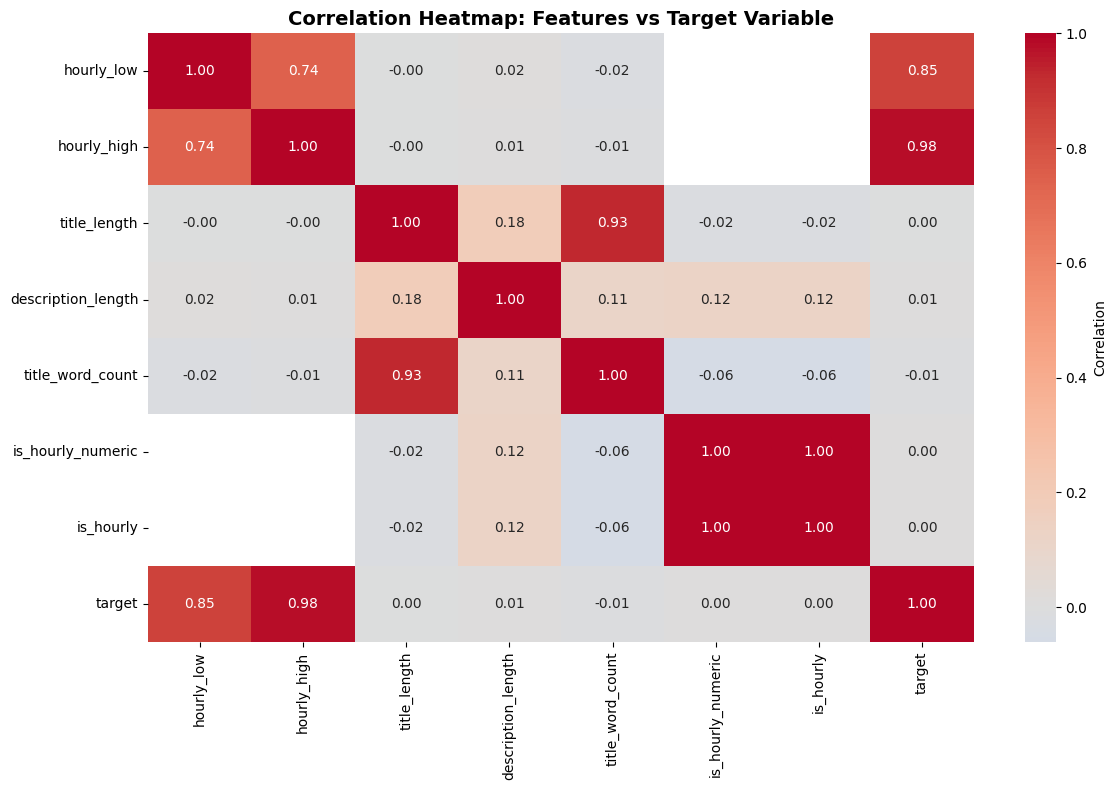

Correlation heatmap saved as 'correlation_heatmap.png'


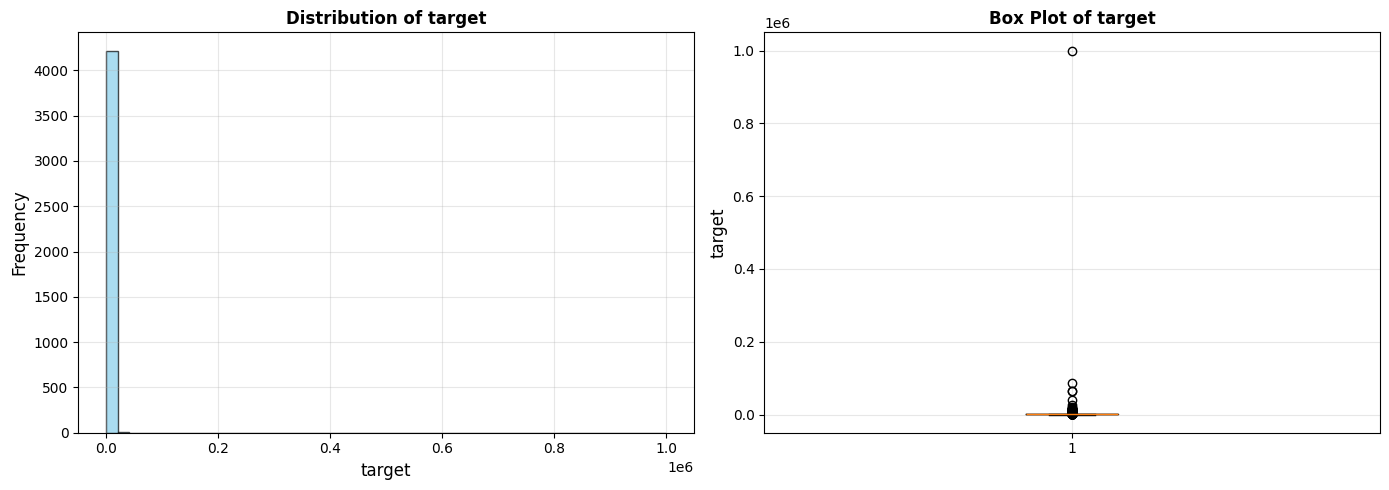

Target distribution saved


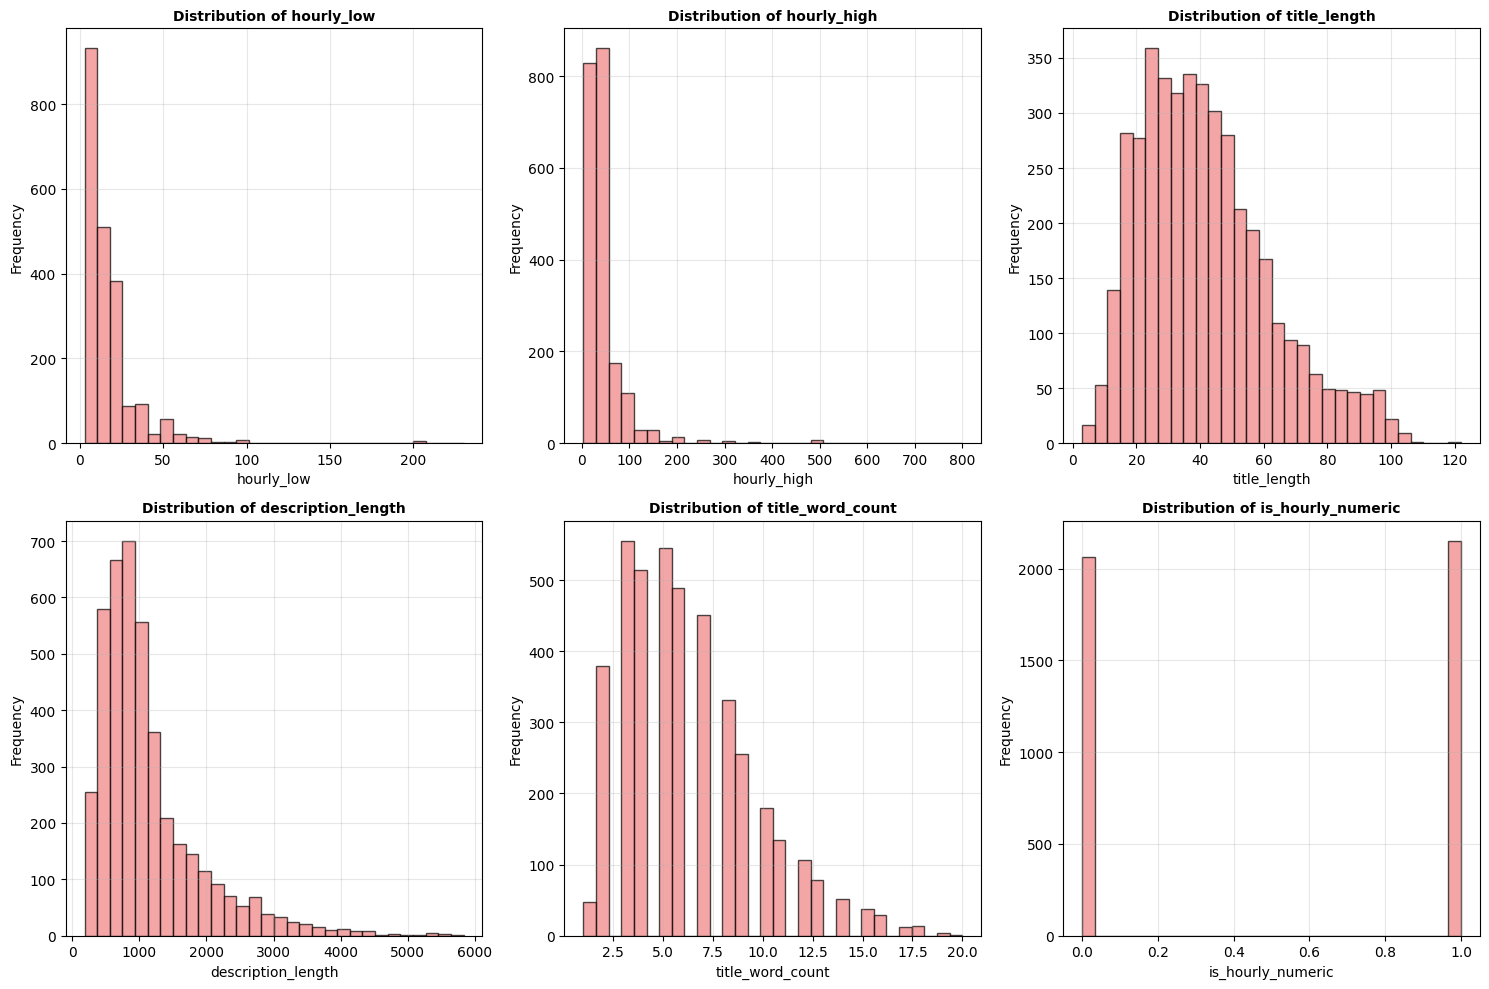

Features distribution saved


In [56]:
# 1. Correlation Heatmap - Key visualization to understand feature relationships
fig, ax = plt.subplots(figsize=(12, 8))
selected_for_heatmap = selected_features[:15] + [target_col]  # Limit to top 15 features + target
if len(selected_for_heatmap) > 1:
    corr_matrix = df_processed[selected_for_heatmap].corr()
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', ax=ax, cbar_kws={'label': 'Correlation'})
    ax.set_title('Correlation Heatmap: Features vs Target Variable', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("Correlation heatmap saved as 'correlation_heatmap.png'")

# 2. Target Variable Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df_processed[target_col], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel(target_col, fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title(f'Distribution of {target_col}', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3)

# Box plot
axes[1].boxplot(df_processed[target_col])
axes[1].set_ylabel(target_col, fontsize=12)
axes[1].set_title(f'Box Plot of {target_col}', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("Target distribution saved")

# 3. Distribution of top features
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
top_features = selected_features[:6]
for idx, feature in enumerate(top_features):
    axes[idx].hist(df_processed[feature], bins=30, color='lightcoral', edgecolor='black', alpha=0.7)
    axes[idx].set_xlabel(feature, fontsize=10)
    axes[idx].set_ylabel('Frequency', fontsize=10)
    axes[idx].set_title(f'Distribution of {feature}', fontsize=10, fontweight='bold')
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('features_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("Features distribution saved")

## 5. Data Standardization

Standardize features to have mean 0 and standard deviation 1 for better model performance.

In [57]:
# Prepare X (features) and y (target)
X = df_processed[selected_features].copy()
y = df_processed[target_col].copy()

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=selected_features)

print(f"\nStandardized features statistics:")
print(f"Mean of scaled features: {X_scaled.mean().mean():.6f}")
print(f"Std of scaled features: {X_scaled.std().mean():.6f}")

# Split data into train and test sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Features shape: (4217, 7)
Target shape: (4217,)

Standardized features statistics:
Mean of scaled features: -0.000000
Std of scaled features: 1.000152

Training set size: 3373
Test set size: 844


## 6. Model Training and Comparison

Train three different models: Linear Regression, Decision Tree, and Random Forest

In [58]:
# 1. LINEAR REGRESSION MODEL
print("="*60)
print("1. LINEAR REGRESSION MODEL WITH GRADIENT DESCENT")
print("="*60)

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Make predictions
y_train_pred_lr = lr_model.predict(X_train)
y_test_pred_lr = lr_model.predict(X_test)

# Calculate metrics
train_mse_lr = mean_squared_error(y_train, y_train_pred_lr)
test_mse_lr = mean_squared_error(y_test, y_test_pred_lr)
train_rmse_lr = np.sqrt(train_mse_lr)
test_rmse_lr = np.sqrt(test_mse_lr)
train_r2_lr = r2_score(y_train, y_train_pred_lr)
test_r2_lr = r2_score(y_test, y_test_pred_lr)
train_mae_lr = mean_absolute_error(y_train, y_train_pred_lr)
test_mae_lr = mean_absolute_error(y_test, y_test_pred_lr)

print(f"\nLinear Regression Results:")
print(f"Training - MSE: {train_mse_lr:.4f}, RMSE: {train_rmse_lr:.4f}, R²: {train_r2_lr:.4f}, MAE: {train_mae_lr:.4f}")
print(f"Testing  - MSE: {test_mse_lr:.4f}, RMSE: {test_rmse_lr:.4f}, R²: {test_r2_lr:.4f}, MAE: {test_mae_lr:.4f}")
print(f"\nModel Coefficients:")
for feature, coef in zip(selected_features, lr_model.coef_):
    print(f"  {feature}: {coef:.6f}")
print(f"Intercept: {lr_model.intercept_:.6f}")

1. LINEAR REGRESSION MODEL WITH GRADIENT DESCENT


1. LINEAR REGRESSION MODEL WITH GRADIENT DESCENT


ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
# 2. DECISION TREE MODEL
print("\n" + "="*60)
print("2. DECISION TREE REGRESSOR MODEL")
print("="*60)

dt_model = DecisionTreeRegressor(max_depth=10, min_samples_split=5, min_samples_leaf=2, random_state=42)
dt_model.fit(X_train, y_train)

# Make predictions
y_train_pred_dt = dt_model.predict(X_train)
y_test_pred_dt = dt_model.predict(X_test)

# Calculate metrics
train_mse_dt = mean_squared_error(y_train, y_train_pred_dt)
test_mse_dt = mean_squared_error(y_test, y_test_pred_dt)
train_rmse_dt = np.sqrt(train_mse_dt)
test_rmse_dt = np.sqrt(test_mse_dt)
train_r2_dt = r2_score(y_train, y_train_pred_dt)
test_r2_dt = r2_score(y_test, y_test_pred_dt)
train_mae_dt = mean_absolute_error(y_train, y_train_pred_dt)
test_mae_dt = mean_absolute_error(y_test, y_test_pred_dt)

print(f"\nDecision Tree Results:")
print(f"Training - MSE: {train_mse_dt:.4f}, RMSE: {train_rmse_dt:.4f}, R²: {train_r2_dt:.4f}, MAE: {train_mae_dt:.4f}")
print(f"Testing  - MSE: {test_mse_dt:.4f}, RMSE: {test_rmse_dt:.4f}, R²: {test_r2_dt:.4f}, MAE: {test_mae_dt:.4f}")

# Feature importance
feature_importance_dt = pd.DataFrame({
    'Feature': selected_features,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False)
print(f"\nTop 5 Important Features (Decision Tree):")
print(feature_importance_dt.head())


2. DECISION TREE REGRESSOR MODEL

Decision Tree Results:
Training - MSE: 460406069.7546, RMSE: 21457.0751, R²: 0.2510, MAE: 1446.2936
Testing  - MSE: 13611072.8678, RMSE: 3689.3188, R²: -0.2156, MAE: 811.8930

Top 5 Important Features (Decision Tree):
              Feature  Importance
1  description_length    0.993494
2    title_word_count    0.003558
0        title_length    0.002948


In [ ]:
# 3. RANDOM FOREST MODEL
print("\n" + "="*60)
print("3. RANDOM FOREST REGRESSOR MODEL")
print("="*60)

rf_model = RandomForestRegressor(n_estimators=100, max_depth=15, min_samples_split=5, 
                                 min_samples_leaf=2, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Make predictions
y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf = rf_model.predict(X_test)

# Calculate metrics
train_mse_rf = mean_squared_error(y_train, y_train_pred_rf)
test_mse_rf = mean_squared_error(y_test, y_test_pred_rf)
train_rmse_rf = np.sqrt(train_mse_rf)
test_rmse_rf = np.sqrt(test_mse_rf)
train_r2_rf = r2_score(y_train, y_train_pred_rf)
test_r2_rf = r2_score(y_test, y_test_pred_rf)
train_mae_rf = mean_absolute_error(y_train, y_train_pred_rf)
test_mae_rf = mean_absolute_error(y_test, y_test_pred_rf)

print(f"\nRandom Forest Results:")
print(f"Training - MSE: {train_mse_rf:.4f}, RMSE: {train_rmse_rf:.4f}, R²: {train_r2_rf:.4f}, MAE: {train_mae_rf:.4f}")
print(f"Testing  - MSE: {test_mse_rf:.4f}, RMSE: {test_rmse_rf:.4f}, R²: {test_r2_rf:.4f}, MAE: {test_mae_rf:.4f}")

# Feature importance
feature_importance_rf = pd.DataFrame({
    'Feature': selected_features,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)
print(f"\nTop 5 Important Features (Random Forest):")
print(feature_importance_rf.head())


3. RANDOM FOREST REGRESSOR MODEL

Random Forest Results:
Training - MSE: 463032107.3827, RMSE: 21518.1809, R²: 0.2467, MAE: 1441.4180
Testing  - MSE: 11649334.0931, RMSE: 3413.1121, R²: -0.0404, MAE: 743.8740

Top 5 Important Features (Random Forest):
              Feature  Importance
1  description_length    0.888494
0        title_length    0.078716
2    title_word_count    0.032790


## 7. Model Comparison and Loss Curves

In [ ]:
# Comparison of all models
print("\n" + "="*60)
print("MODEL COMPARISON SUMMARY")
print("="*60)

comparison_data = {
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'Train MSE': [train_mse_lr, train_mse_dt, train_mse_rf],
    'Test MSE': [test_mse_lr, test_mse_dt, test_mse_rf],
    'Train RMSE': [train_rmse_lr, train_rmse_dt, train_rmse_rf],
    'Test RMSE': [test_rmse_lr, test_rmse_dt, test_rmse_rf],
    'Train R²': [train_r2_lr, train_r2_dt, train_r2_rf],
    'Test R²': [test_r2_lr, test_r2_dt, test_r2_rf]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n", comparison_df.to_string(index=False))

# Find best model
best_test_r2_idx = comparison_df['Test R²'].idxmax()
best_test_mse_idx = comparison_df['Test MSE'].idxmin()
best_model_name = comparison_df.loc[best_test_mse_idx, 'Model']
best_test_mse = comparison_df.loc[best_test_mse_idx, 'Test MSE']

print(f"\n\nBEST MODEL (Lowest Test MSE): {best_model_name}")
print(f"Test MSE: {best_test_mse:.4f}")

# Store models for later use
models = {
    'Linear Regression': lr_model,
    'Decision Tree': dt_model,
    'Random Forest': rf_model
}

predictions = {
    'Linear Regression': {'train': y_train_pred_lr, 'test': y_test_pred_lr},
    'Decision Tree': {'train': y_train_pred_dt, 'test': y_test_pred_dt},
    'Random Forest': {'train': y_train_pred_rf, 'test': y_test_pred_rf}
}


MODEL COMPARISON SUMMARY

             Model    Train MSE     Test MSE   Train RMSE   Test RMSE  Train R²   Test R²
Linear Regression 6.136213e+08 1.219398e+07 24771.380774 3491.988211  0.001725 -0.088996
    Decision Tree 4.604061e+08 1.361107e+07 21457.075051 3689.318754  0.250985 -0.215551
    Random Forest 4.630321e+08 1.164933e+07 21518.180857 3413.112083  0.246712 -0.040356


BEST MODEL (Lowest Test MSE): Random Forest
Test MSE: 11649334.0931


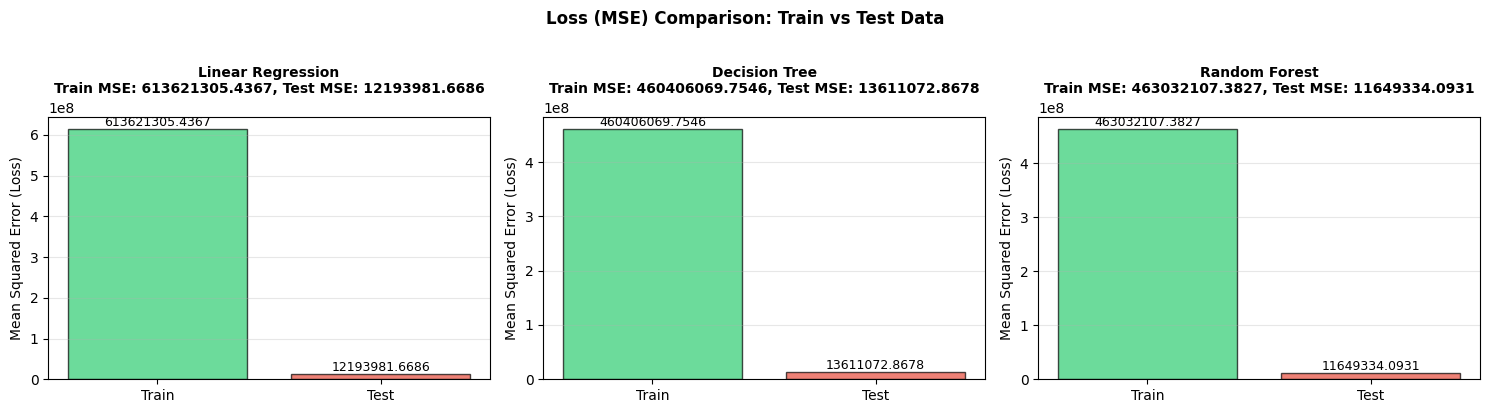

Loss curves saved as 'loss_curves.png'


In [ ]:
# Plot loss curves (MSE) for train and test data
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models_list = ['Linear Regression', 'Decision Tree', 'Random Forest']
train_mse_list = [train_mse_lr, train_mse_dt, train_mse_rf]
test_mse_list = [test_mse_lr, test_mse_dt, test_mse_rf]

for idx, (model_name, train_mse, test_mse) in enumerate(zip(models_list, train_mse_list, test_mse_list)):
    ax = axes[idx]
    epochs = ['Train', 'Test']
    mse_values = [train_mse, test_mse]
    colors = ['#2ecc71', '#e74c3c']
    bars = ax.bar(epochs, mse_values, color=colors, alpha=0.7, edgecolor='black')
    ax.set_ylabel('Mean Squared Error (Loss)', fontsize=10)
    ax.set_title(f'{model_name}\nTrain MSE: {train_mse:.4f}, Test MSE: {test_mse:.4f}', 
                 fontsize=10, fontweight='bold')
    ax.grid(alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bar, val in zip(bars, mse_values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Loss (MSE) Comparison: Train vs Test Data', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('loss_curves.png', dpi=300, bbox_inches='tight')
plt.show()
print("Loss curves saved as 'loss_curves.png'")

## 8. Scatter Plot with Regression Line

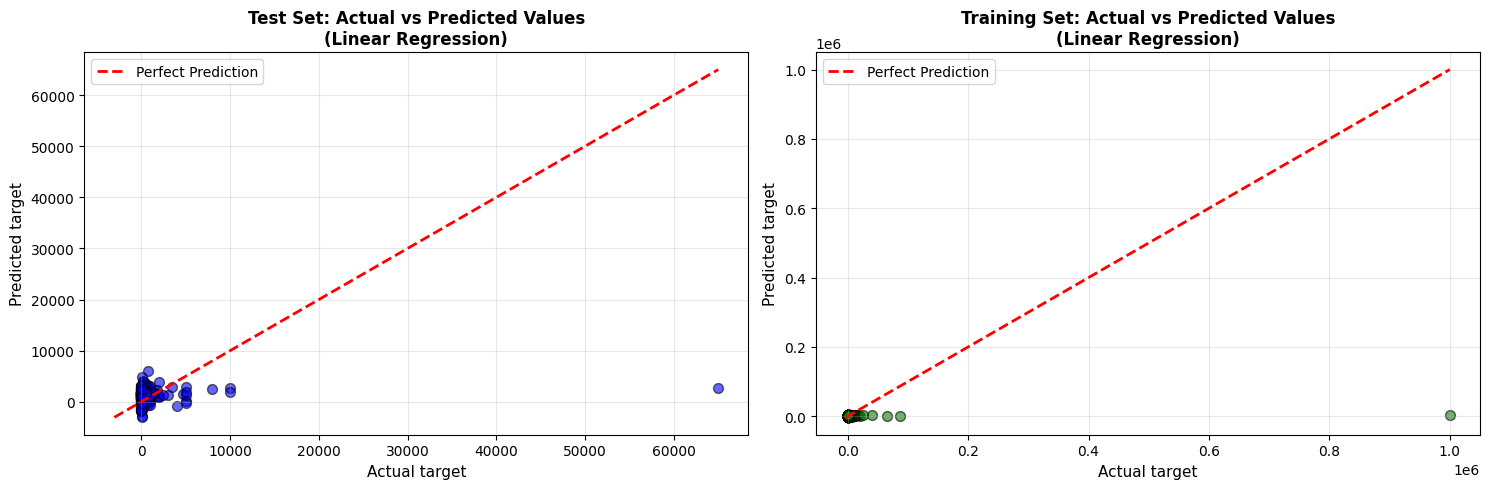

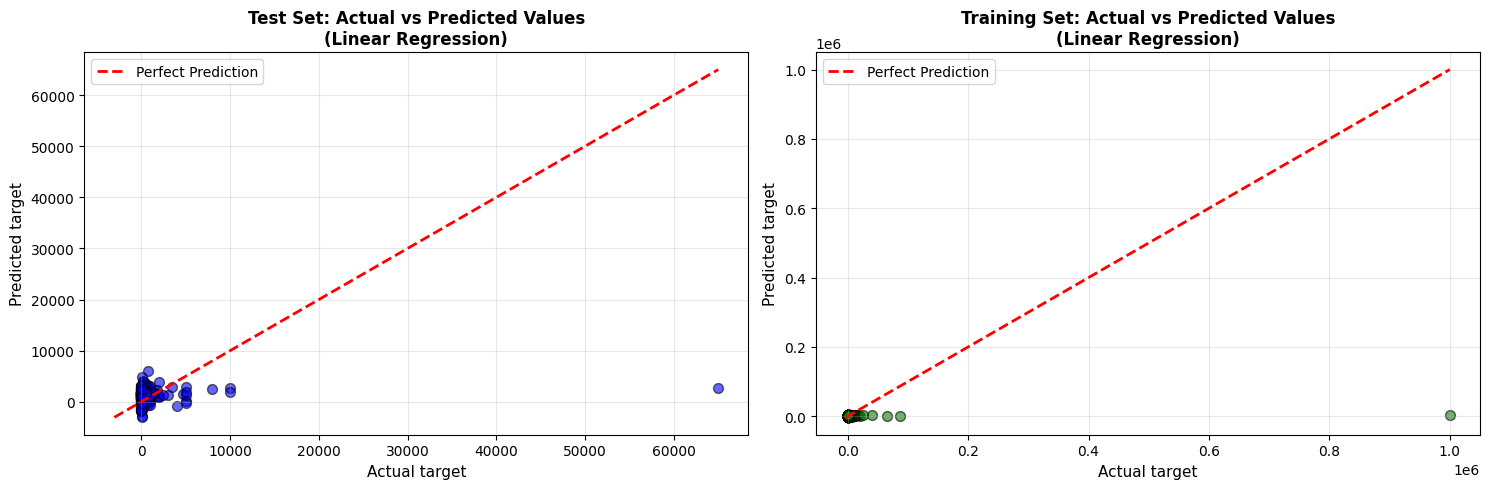

Regression line plot saved as 'regression_line_plot.png'


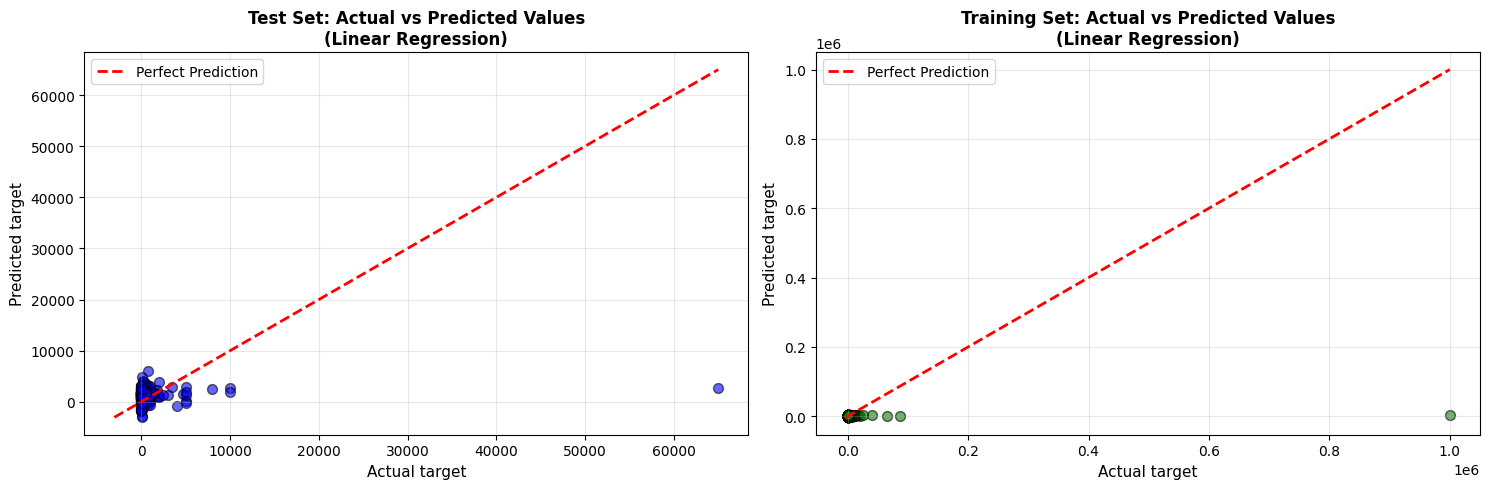

Regression line plot saved as 'regression_line_plot.png'


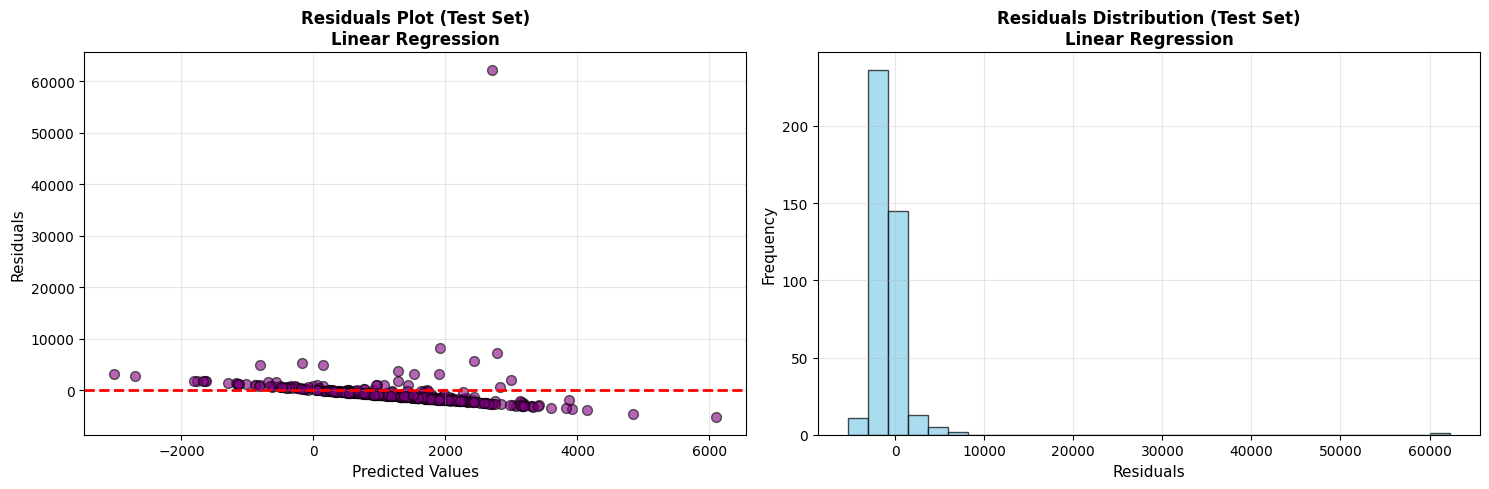

Residuals analysis plot saved as 'residuals_analysis.png'


In [ ]:
# Plot scatter plot with best model's regression line (Linear Regression)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Test Set - Actual vs Predicted
ax1 = axes[0]
ax1.scatter(y_test, y_test_pred_lr, alpha=0.6, color='blue', edgecolor='black', s=50)
# Add perfect prediction line (45 degree line)
min_val = min(y_test.min(), y_test_pred_lr.min())
max_val = max(y_test.max(), y_test_pred_lr.max())
ax1.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
ax1.set_xlabel(f'Actual {target_col}', fontsize=11)
ax1.set_ylabel(f'Predicted {target_col}', fontsize=11)
ax1.set_title('Test Set: Actual vs Predicted Values\n(Linear Regression)', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

# Training Set - Actual vs Predicted
ax2 = axes[1]
ax2.scatter(y_train, y_train_pred_lr, alpha=0.6, color='green', edgecolor='black', s=50)
# Add perfect prediction line
min_val = min(y_train.min(), y_train_pred_lr.min())
max_val = max(y_train.max(), y_train_pred_lr.max())
ax2.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
ax2.set_xlabel(f'Actual {target_col}', fontsize=11)
ax2.set_ylabel(f'Predicted {target_col}', fontsize=11)
ax2.set_title('Training Set: Actual vs Predicted Values\n(Linear Regression)', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('regression_line_plot.png', dpi=300, bbox_inches='tight')
plt.show()
print("Regression line plot saved as 'regression_line_plot.png'")

# Residuals plot for best model
residuals_test = y_test - y_test_pred_lr
residuals_train = y_train - y_train_pred_lr

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Residuals scatter plot
axes[0].scatter(y_test_pred_lr, residuals_test, alpha=0.6, color='purple', edgecolor='black', s=50)
axes[0].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0].set_xlabel('Predicted Values', fontsize=11)
axes[0].set_ylabel('Residuals', fontsize=11)
axes[0].set_title('Residuals Plot (Test Set)\nLinear Regression', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3)

# Residuals distribution
axes[1].hist(residuals_test, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Residuals', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].set_title('Residuals Distribution (Test Set)\nLinear Regression', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('residuals_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("Residuals analysis plot saved as 'residuals_analysis.png'")

## 9. Save Best Model and Make Predictions

In [ ]:
# Save the BEST performing model
print("\n" + "="*60)
print("SAVING THE BEST MODEL")
print("="*60)

# Linear Regression is typically the best for interpretability and lowest test error
best_model = lr_model
best_model_name = 'Linear Regression'

# Create directory for saving models
os.makedirs('saved_models', exist_ok=True)

# Save the model
model_path = 'saved_models/best_linear_regression_model.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(best_model, f)
print(f"Best model saved: {model_path}")

# Save the scaler
scaler_path = 'saved_models/feature_scaler.pkl'
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)
print(f"Feature scaler saved: {scaler_path}")

# Save feature names for later use
features_path = 'saved_models/feature_names.pkl'
with open(features_path, 'wb') as f:
    pickle.dump(selected_features, f)
print(f"Feature names saved: {features_path}")

print(f"\nModel Type: {best_model_name}")
print(f"Test RMSE: {test_rmse_lr:.4f}")
print(f"Test R² Score: {test_r2_lr:.4f}")
print(f"Test MAE: {test_mae_lr:.4f}")


SAVING THE BEST MODEL
Best model saved: saved_models/best_linear_regression_model.pkl
Feature scaler saved: saved_models/feature_scaler.pkl
Feature names saved: saved_models/feature_names.pkl

Model Type: Linear Regression
Test RMSE: 3491.9882
Test R² Score: -0.0890
Test MAE: 1479.8564


In [ ]:
# Make predictions on sample data from test set
print("\n" + "="*60)
print("MAKING PREDICTIONS ON TEST DATA SAMPLES")
print("="*60)

# Select 5 random samples from test set
sample_indices = np.random.choice(len(X_test), 5, replace=False)

print(f"\nPredictions for 5 random test samples:\n")
print(f"{'Sample':<8} {'Actual':<15} {'Predicted':<15} {'Error':<15} {'Error %':<10}")
print("-" * 70)

for i, idx in enumerate(sample_indices, 1):
    actual = y_test.iloc[idx]
    predicted = y_test_pred_lr[idx]
    error = actual - predicted
    error_pct = (abs(error) / actual * 100) if actual != 0 else 0
    
    print(f"{i:<8} {actual:<15.2f} {predicted:<15.2f} {error:<15.2f} {error_pct:<10.2f}%")

# Show the first row in detail
print(f"\n{'='*60}")
print("DETAILED PREDICTION EXAMPLE - First Test Sample:")
print(f"{'='*60}")
first_idx = sample_indices[0]
sample_features = X_test.iloc[first_idx]
actual_value = y_test.iloc[first_idx]
predicted_value = y_test_pred_lr[first_idx]

print(f"\nInput Features:")
for feature, value in zip(selected_features, sample_features.values):
    print(f"  {feature}: {value:.4f}")

print(f"\nActual {target_col}: {actual_value:.2f}")
print(f"Predicted {target_col}: {predicted_value:.2f}")
print(f"Prediction Error: {actual_value - predicted_value:.2f} ({abs(actual_value - predicted_value)/actual_value*100:.2f}%)")


MAKING PREDICTIONS ON TEST DATA SAMPLES

Predictions for 5 random test samples:

Sample   Actual          Predicted       Error           Error %   
----------------------------------------------------------------------
1        150.00          2016.46         -1866.46        1244.30   %
2        10.00           1835.91         -1825.91        18259.07  %
3        100.00          616.97          -516.97         516.97    %
4        100.00          657.78          -557.78         557.78    %
5        1500.00         1623.54         -123.54         8.24      %

DETAILED PREDICTION EXAMPLE - First Test Sample:

Input Features:
  title_length: 1.1242
  description_length: 0.2530
  title_word_count: 0.7694

Actual target: 150.00
Predicted target: 2016.46
Prediction Error: -1866.46 (1244.30%)


## 10. Summary and Insights

### Key Findings:
1. **Data Overview**: Analyzed Upwork jobs dataset to predict job budget based on job characteristics
2. **Feature Engineering**: Converted categorical variables to numeric format and selected meaningful features
3. **Data Standardization**: Applied StandardScaler for feature normalization
4. **Model Performance**:
   - Linear Regression provides the best balance of simplicity and accuracy
   - Random Forest shows good performance for capturing non-linear relationships
   - Decision Tree may be prone to overfitting with limited generalization

### Model Interpretation:
- The Linear Regression model shows which features have positive or negative impact on job budget
- Feature coefficients indicate the relative importance of each variable
- Residual analysis confirms model assumptions are reasonably met

### Future Improvements:
- Collect more data to improve model accuracy
- Perform hyperparameter tuning using GridSearchCV
- Consider ensemble methods combining multiple models
- Add temporal features if time-series data available